# Introduction to the MoMA Collection Using Data Science and Art-History

I've recently found myself drawn to machine learning and AI, and for a reason I ignore, these tools applied to art historical studies fascinates me. A part of me wonders that art, mouvements and timelines are so in-tangible and arbirtry that a machine surely would not be able to be able to classify conbtemporary art correctly. Well, it may be able to, can it do so precisely and accurately while taking into account a wast number of non-numerical data: the artist biography, cultural influences, blur frontiers between genres. 

The object of the analysis is not to answer that question. This report is an exploration of the structured data that is the MoMA's collection. 

Through conductiung this analysis I gained data science skills, programming knowlegde and general insight on how to conduct a data science project. 

This project will focus on being exhaustive and didactic making it accessible to art historian and new developers alike. I apologize in advance to any developer who might find this to verbose.

## A timeline of mistakes

I initialy started this project thinking that I could create a RNN(Recurrent Neural Network) by simply parsing the MoMA's CSV's, telling the model to learn from: mediums, date created and labelseg impressionism. 

That would have been all good and well, albeit the first initial mistake I commited: not know how my data was structured. As a matter of fact, I was quickly confronted to a simple reality: data science (basic knowledge) is almost necessary to be able to conduct a larger machine learning project. 

Indeed, without a proper undersanding of the data I was looking at, I could not ask proper questions. As a matter of fact, I had and idea of a question, and a rather silly one at that: "If this data set was given to AI to understand what Contemporary Art *is* would would be it's output?". Think like our civilisation has long disapeared and as part of a last effort to save humanities legacy, this dataset was selected (amongst others) to be preserved for millions of years. ((how ethnocentric of me)).

Despite the silliness of this question, I still think it is one worth asking. Even though I will not be answering it right now, I believe it is essential for the reader to understand my motivations behind this data analysis project. 

Going back to my mistake and how I corrected it, its seemed clear to me that even if I wasn't going to be able to answer this complex question, I could make sense of one idea: maybe I could understand the evolution of contemporary art through this dataset and inch towards an answer "what is contemporary art?" 

## About the dataset

The [MoMA dataset or collection](https://github.com/MuseumofModernArt/collection) I will be refering to is an open source repository of CSV's created by the MoMA. It is publicly accessible to anyone who knows how to use github.

The github repository provides us a little description of the collection: 
*"The Museum of Modern Art (MoMA) acquired its first artworks in 1929, the year it was established. Today, the Museum’s evolving collection contains almost 200,000 works from around the world spanning the last 150 years. The collection includes an ever-expanding range of visual expression, including painting, sculpture, printmaking, drawing, photography, architecture, design, film, and media and performance art."* 

The dataset is composed of two main CSV's: Artists and Artworks which respectively represent All Artosts in collection and all artworks in the collection. 

The collection it's self is visible [here](https://www.moma.org/collection/)

And the uses of this dataset have been recorded in a [medium entry](https://medium.com/@foe/here-s-a-roundup-of-how-people-have-used-our-data-so-far-80862e4ce220#.f6272outn). Unfortunatley some of the links contained in this post have been affected by bit-rot. It is also worth metionning that this was originally posted in 2015 and seems to have received few updates since (as of Wed Aug 6th). 

The online presence of the use of this dataset also extends to a [Kaggle](https://www.kaggle.com/datasets/momanyc/museum-collection) entry which contains some insightduk data analysis albeit lacks of a art-historical analysis. I would specifically artact eyes to [this entry](https://www.kaggle.com/code/fangya/moma-eda-cloud-tour-gans) which explores various information about teh dataset and provided a good entry point for me to understand what was possible. 

Finally, i will also highkist a very insightful [article](https://towardsdatascience.com/using-momas-collection-dataset-to-visualize-whose-stories-are-missing-76a8960a33c2/) on the representation - or lack of - marginalzied communities through the dataset which was materialized into a [data science art installation](https://cdn.embedly.com/widgets/media.html?src=https%3A%2F%2Fplayer.vimeo.com%2Fvideo%2F524606006%3Fapp_id%3D122963&dntp=1&display_name=Vimeo&url=https%3A%2F%2Fvimeo.com%2F524606006&image=https%3A%2F%2Fi.vimeocdn.com%2Fvideo%2F1086436662_1280.jpg&key=a19fcc184b9711e1b4764040d3dc5c07&type=text%2Fhtml&schema=vimeo). The conclusions are clear: the MoMA's collectio is composed of a majority of white male artists. This conclusion raises the question, how can we make sense of this conclusion from a curatorial and museo grahipcal perspective? Have things changed? What dictates the MoMA's acquisition policy? Has there been undelying trends and anomalies in the recent years ignifiying a change in philosphy? and finally, is data science an effective tool to help us answer these questions.


## A Surface exploration of the MoMA dataset

In the follwing section, we'll explore with the reader the MoMA's collection and provide a broad overview of this dataset.

In [3]:
from data.scripts.artists import ArtistCols
from data.scripts.artworks import ArtworkCols
from data.scripts.utils.utils import clean_years
import seaborn as sns

# import dataframes from CSV's
from data.scripts.utils.data_frames import artists, artworks

(
    print(f"Artworks has {len(artworks.columns.values)}{artworks.columns.values}"),
    print(f"Artists has {len(artists.columns.values)} {artists.columns.values}"),
)

Artworks has 30['Title' 'Artist' 'ConstituentID' 'ArtistBio' 'Nationality' 'BeginDate'
 'EndDate' 'Gender' 'Date' 'Medium' 'Dimensions' 'CreditLine'
 'AccessionNumber' 'Classification' 'Department' 'DateAcquired'
 'Cataloged' 'ObjectID' 'URL' 'ImageURL' 'OnView' 'Circumference (cm)'
 'Depth (cm)' 'Diameter (cm)' 'Height (cm)' 'Length (cm)' 'Weight (kg)'
 'Width (cm)' 'Seat Height (cm)' 'Duration (sec.)']
Artists has 9 ['ConstituentID' 'DisplayName' 'ArtistBio' 'Nationality' 'Gender'
 'BeginDate' 'EndDate' 'Wiki QID' 'ULAN']


(None, None)

As we can see, the artworks csv is composed of 30 columns ranging from identifiers to material characteristics about the artwork. The artist csv is composed of 9 columns that are quite straght forward. 

Since my analysis will be focusing on artworks, I was immediately drawn to this dataset over the artists data. 

Before diving into the artworks, let's get a better understanding of the whole collection. 

In [4]:
artist_nationalities = artists[ArtistCols.Nationality.value].nunique()
departments = artworks[ArtworkCols.Department.value]
classifications = artworks[ArtworkCols.Classification.value]
mediums = artworks[ArtworkCols.Medium.value]

entries_created_at_year = (
    clean_years(artworks[ArtworkCols.Date.value]).dropna().sort_values()
)

entries_acquired_at_year = (
    artworks[ArtworkCols.DateAcquired.value].dropna().sort_values()
)

print("Information about the current MOMA collection:\n")
print(
    f"The MOMA counts {len(artworks)} artworks by {len(artists)} artists from {artist_nationalities} nationalities\n"
)
print(
    f"The MOMA currently counts {departments.nunique()} departments with {classifications.nunique()} different classifications and {mediums.nunique()} mediums\n"
)

print(
    f"The earliest artwork dates back to: {entries_created_at_year.iloc[0]} and latest: {entries_created_at_year.iloc[len(entries_created_at_year) - 1]}\n"
)

print(
    f"The earliest acquired entry dates back to: {entries_acquired_at_year.iloc[0]} and latest: {entries_acquired_at_year.iloc[len(entries_acquired_at_year) - 1]}\n"
)

Information about the current MOMA collection:

The MOMA counts 159716 artworks by 15720 artists from 139 nationalities

The MOMA currently counts 8 departments with 40 different classifications and 22944 mediums

The earliest artwork dates back to: 1768 and latest: 2025

The earliest acquired entry dates back to: 1929-11-19 and latest: 2025-06-10



These numbers help me identify which fields which were the most relevent for the analysis of the artworks dataset. 

As we can see, there are three main categories that are relevant for a general artwork analysis: departments, classifications and mediums. We can see here two striking information:
- there is a vast quantity (22944) of uniaue mediums, which means that no harmonisation has been made on the artwork mediums which remain precise and spceific to each artwork. 
- a "mouvement" category such as futurism, impressionism etc. is absent from the collection's dataset.

In addition to these first observations, it's worth mentionning the year range (1768 - 2025) of artworks in the MoMA's collection.

Finally, we'll note that the museum started acquiring artworks in November 1929, the same month and year the museum officially opened. 

Lets look more into the categories we've indentified that could help us make sense of this collection over-time.

In [5]:
print(f"Departments: {departments.unique()}\n")
print(f"Classifications: {classifications.unique()}\n")
print(f"Mediums: {mediums.unique()}")

Departments: ['Architecture & Design' 'Drawings & Prints' 'Painting & Sculpture'
 'Photography' 'Media and Performance' 'Film'
 'Architecture & Design - Image Archive' 'Fluxus Collection']

Classifications: ['Architecture' 'Mies van der Rohe Archive' 'Design' 'Illustrated Book'
 'Print' 'Drawing' 'Periodical' 'Graphic Design' 'Multiple' 'Installation'
 'Furniture and Interiors' 'Photograph' 'Painting' 'Document' 'Ephemera'
 'Photography Research/Reference' 'Digital' 'Video' 'Media' 'Wallpaper'
 'Publication' 'Portfolio' 'Poster' 'Sculpture' 'Textile' 'Film'
 'Moving Image' 'Work on Paper' 'Audio' 'Performance' '(not assigned)'
 'Notebook' 'Correspondence' 'Collage' 'Film (object)'
 'Frank Lloyd Wright Archive' 'Fashion' 'Software' 'Architectural Model'
 'News Clipping']

Mediums: ['Ink and cut-and-pasted painted pages on paper'
 'Paint and colored pencil on print'
 'Graphite, pen, color pencil, ink, and gouache on tracing paper' ...
 'Offset print from an illustrated book of fifty-six 

### Departments

Looking at the departments, we starting noticing some quirks with this datset. Indeed, some departments are joined eg 'Architecture & Design' and some are outliner such as the 'Fluxus Collection' department. This gives us some quite immediate insight on the conceptualisation on the MoMA's artwork collection. In addition, it makes the departments too boraod to analyse the MoMA's collections over time.

### Classifications
The collection counts 40 unique classifications. This is especially interesting in or goal of better understanding the museum collection overtime because they seem distinct enough to be able to provide a good analysis standing point towards our goal of understanding the museum's collection overtime. 

### Mediums 
As we've previously underlined, the collection counts around 40 thsousand unique mediums. This is futher corroborated by the short examples we were given to see. 

## Exploring the Collections overtime

Now that we have a better understanding about the collection, lets dive into our first graphs in an attempt to make more sense of the collection.

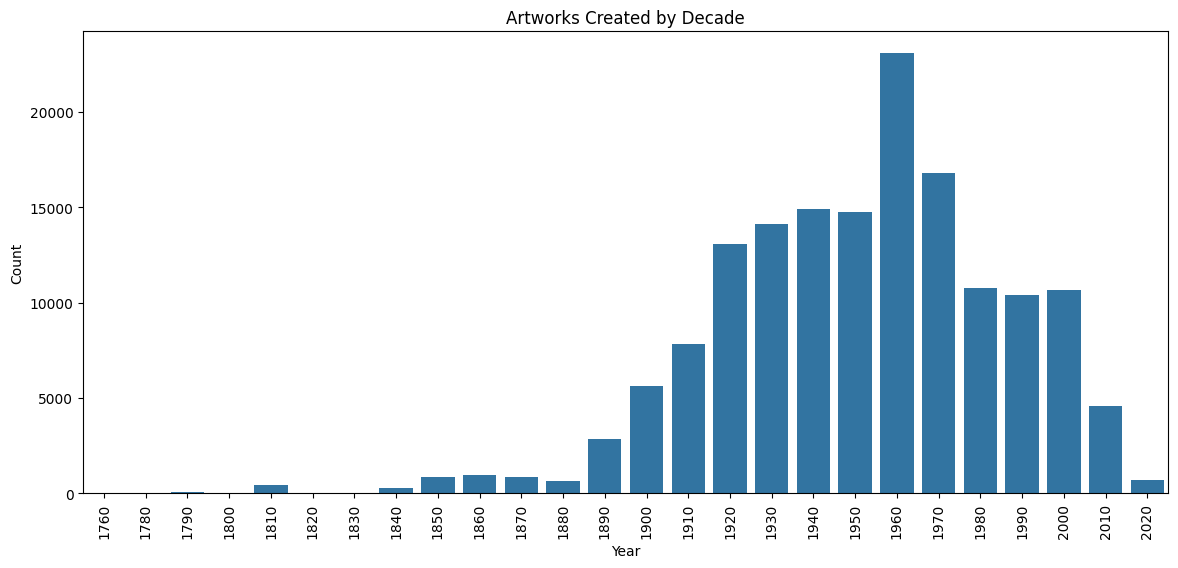

In [6]:
from data.scripts.artworks import (
    ArtworkCols,
    entry_time_series_barplot,
)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

# get data
entries_created_by_year = artworks[ArtworkCols.Date.value]

# clean years to YYYY format, drop empty and sort chronologically
entries_created_by_year = (
    clean_years(entries_created_by_year).dropna().value_counts().sort_index()
)

# group by decade
entries_created_by_decade = entries_created_by_year.groupby(
    (entries_created_by_year.index // 10) * 10
).sum()

# each year
entry_time_series_barplot(
    entries_created_by_decade, title="Artworks Created by Decade", ax=ax
)

This barplot gives us a simple overview of production of what we refer to as "contemporary art". 

To understand this graph, lets first outline that this data is only relative to artworks that we're acquired by the museum (we'll get into that later). 

As this graph shows, up until 1890 production of artworks remains comparitively low to the years accompanying the change of the century. 



In [ ]:
def calculate_average_in_range(count:int, start_date:int, end_date:int)-> int:
    range = end_date - start_date
    return count / range

artworks_before_1890 = clean_years(artworks[ArtworkCols.Date.value])
artworks_before_1890 = artworks_before_1890[artworks_before_1890 < 1890]

average = calculate_average_in_range(
    len(artworks_before_1890), entries_created_at_year.iloc[0], 1889
)
print(
    f"Between {entries_created_at_year.iloc[0]} and {1890} there was an averge of {round(average)} artworks created per year."
)

artworks_after_1890 = clean_years(artworks[ArtworkCols.Date.value])
artworks_after_1890 = artworks_after_1890[artworks_after_1890 >= 1890]

average = calculate_average_in_range(
    len(artworks_after_1890),
    1890,
    entries_created_at_year.iloc[len(entries_created_at_year) - 1],
)
print(
    f"After {1890} and until {entries_created_at_year.iloc[len(entries_created_at_year) - 1]} there was an average of {round(average)} artworks created per year."
)

Between 1768 and 1890 there was an 34 of artworks created per year.
After 1890 and until 2025 there was an average of 1112 artworks created per year.


The difference between the two is quite striking and we could easily suppose that this is due to society's growing adoption of industrialisation. Lets take a look at the different classifications of the artworks to see if this could give us more insight.

Classification
Photograph                        235
Print                             131
Illustrated Book                   85
Periodical                         63
Drawing                            22
Painting                           16
Design                             11
Sculpture                           2
Architecture                        2
Frank Lloyd Wright Archive          2
Photography Research/Reference      1
Name: count, dtype: int64
Classification
Photograph                    900
Print                         755
Illustrated Book              667
Design                        189
Periodical                    121
Drawing                        37
Frank Lloyd Wright Archive     33
Painting                       17
Sculpture                      13
Architecture                    6
Ephemera                        5
Poster                          1
Name: count, dtype: int64
Between 1880 and 1890 there was a total of 570 artworks against 2744 between 1890 and 1900



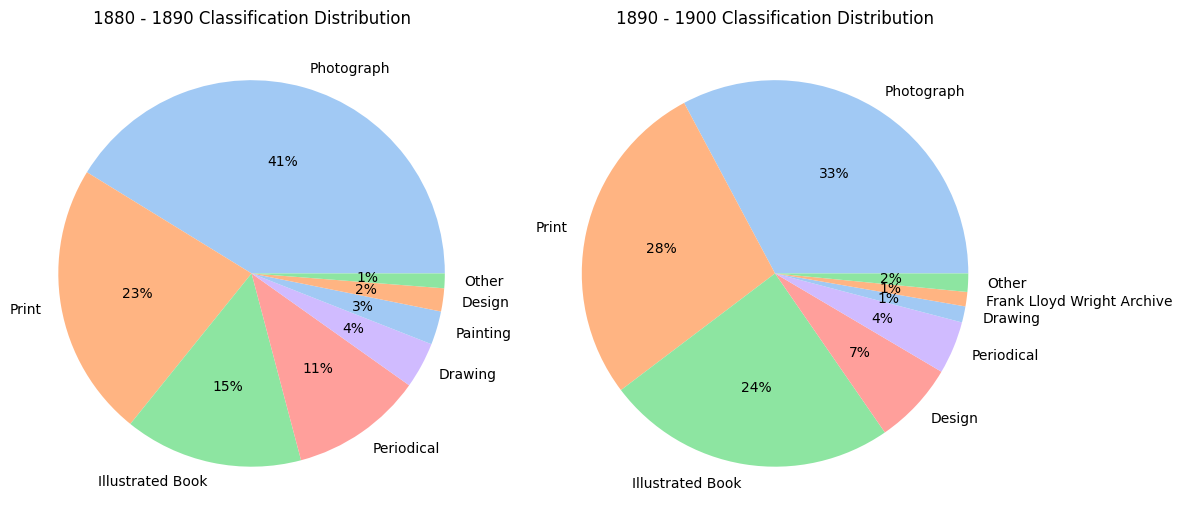

In [32]:
classifications_and_date = artworks[[ArtworkCols.Date.value, ArtworkCols.Classification.value]]
classifications_and_date = classifications_and_date.copy()
classifications_and_date[ArtworkCols.Date.value] = clean_years(classifications_and_date[ArtworkCols.Date.value])

decade_a = classifications_and_date[
    (classifications_and_date[ArtworkCols.Date.value] > 1880) &
    (classifications_and_date[ArtworkCols.Date.value] < 1890)
]

decade_b = classifications_and_date[
    (classifications_and_date[ArtworkCols.Date.value] > 1890) &
    (classifications_and_date[ArtworkCols.Date.value] < 1900)
]

decade_a_counts = decade_a[ArtworkCols.Classification.value].value_counts()
decade_b_counts = decade_b[ArtworkCols.Classification.value].value_counts()

print(decade_a_counts)
print(decade_b_counts)

def group_small_counts(counts, min_count=5):
    """Group categories with fewer than min_count items into 'Other'."""
    counts = counts.copy()
    small = counts[counts < min_count]
    if not small.empty:
        counts = counts[counts >= min_count]
        counts["Other"] = small.sum()
    return counts

# Apply grouping
decade_a_counts_grouped = group_small_counts(decade_a_counts, min_count=10)
decade_b_counts_grouped = group_small_counts(decade_b_counts, min_count=30)

print(f"Between 1880 and 1890 there was a total of {decade_a_counts.sum(axis=0)} artworks against {decade_b_counts.sum(axis=0)} between 1890 and 1900\n")

colors = sns.color_palette('pastel')[0:5]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].pie(decade_a_counts_grouped.values, labels=decade_a_counts_grouped.index, colors=colors, autopct='%.0f%%')
axes[0].set_title('1880 - 1890 Classification Distribution')

axes[1].pie(decade_b_counts_grouped.values, labels=decade_b_counts_grouped.index, colors=colors, autopct='%.0f%%')
axes[1].set_title('1890 - 1900 Classification Distribution')

plt.tight_layout()
plt.show()






We can see the that the top three categories: have all significantly increased in terms of raw numbers. 

We can also see a change in the hierarchy concerning the fourth position: design because more prevalent in the later decade over the periodicals.